# 01 · The first law and energy balances

Compressors, turbines, heat exchangers, nozzles and valves: the equipment of a chemical plant or a power
station is analysed with one equation - the steady-flow energy balance - and property data. This notebook
applies it to real gases and steam, with heat capacities that depend on temperature.

**What you will learn**
- apply the steady-flow energy balance to compressors, turbines, heat exchangers and valves
- use temperature-dependent heat capacities and mean heat capacities
- compute isentropic processes with variable Cp
- recognise irreversibility through isentropic efficiencies

**Before you start:** notebook 00; the first law from an introductory course  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import integrate
from engthermo import idealgas, steam
from engthermo.constants import R
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## The steady-flow energy balance
For a device with one inlet and one outlet, per unit mass or mole of fluid,
$$q - w_s = \Delta h + \Delta(\tfrac12 v^2) + g\,\Delta z,$$
with $q$ the heat added, $w_s$ the shaft work delivered and $\Delta h$ the change in enthalpy. Kinetic and potential
terms are usually negligible in chemical process equipment. Everything then reduces to enthalpy differences,
and enthalpy comes from heat capacities, tables or equations of state.

## Heat capacities depend on temperature

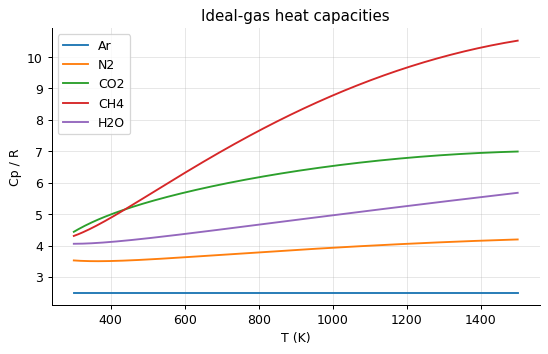

N2: Cp at 300 K 29.3, at 1000 K 32.7 J/(mol K)
CO2: Cp at 300 K 36.9, at 1000 K 54.3 J/(mol K)
CH4: Cp at 300 K 35.8, at 1000 K 73.0 J/(mol K)


In [2]:
T = np.linspace(300, 1500, 200)
for gas in ("Ar", "N2", "CO2", "CH4", "H2O"):
    plt.plot(T, idealgas.cp(gas, T) / R, label=gas)
plt.xlabel("T (K)"); plt.ylabel("Cp / R"); plt.legend(); plt.title("Ideal-gas heat capacities"); plt.show()
for gas in ("N2", "CO2", "CH4"):
    print(f"{gas}: Cp at 300 K {idealgas.cp(gas, 300):.1f}, at 1000 K {idealgas.cp(gas, 1000):.1f} J/(mol K)")

Argon's heat capacity is exactly $5R/2$: a monatomic gas stores energy only in translation. Molecules also
rotate and, increasingly at high temperature, vibrate - so $C_p$ of methane almost doubles between room
temperature and 1000 K. "Constant $C_p$" is a convenient fiction that must be checked.

## Heating a gas stream
A furnace heats 100 mol/s of CO$_2$ from 400 to 1200 K. The heat duty is the enthalpy change:

In [3]:
dH = idealgas.enthalpy_change("CO2", 400.0, 1200.0)
Q = 100.0 * dH
print(f"enthalpy change {dH/1e3:.2f} kJ/mol -> heat duty {Q/1e6:.2f} MW")
print(f"with Cp fixed at its 400 K value: {100 * idealgas.cp('CO2', 400.0) * 800 / 1e6:.2f} MW ({idealgas.cp('CO2', 400.0) * 800 / dH - 1:+.0%})")
print(f"mean heat capacity for this interval: {idealgas.mean_cp_h('CO2', 400.0, 1200.0):.1f} J/(mol K)")

enthalpy change 40.48 kJ/mol -> heat duty 4.05 MW
with Cp fixed at its 400 K value: 3.32 MW (-18%)
mean heat capacity for this interval: 50.6 J/(mol K)


Using the room-temperature heat capacity would undersize the furnace by a fifth. The mean heat capacity
$\langle C_p\rangle_H$ (the integral divided by the temperature interval) is the number that makes the simple
formula $Q = n\langle C_p\rangle_H\Delta T$ exact.

## An air compressor: the work of a real gas
Compressed-air energy storage compresses air from 1 bar and 300 K to 10 bar. For a reversible adiabatic
compressor the outlet temperature follows from constant entropy:

In [4]:
T1, p1, p2 = 300.0, 1e5, 1e6
T2 = idealgas.isentropic_T("air", T1, p1, p2)
T2_gamma = idealgas.isentropic_T_const_gamma(T1, p1, p2, gamma=1.4)
w = idealgas.enthalpy_change("air", T1, T2)
print(f"outlet temperature: variable Cp {T2:.1f} K, constant gamma = 1.4 {T2_gamma:.1f} K")
print(f"compressor work {w/1e3:.3f} kJ/mol = {w / 0.028851 / 1e3:.1f} kJ/kg")
for eta in (0.85, 0.75):
    w_real = w / eta
    T2_real = idealgas.final_T_from_enthalpy("air", T1, w_real)
    print(f"isentropic efficiency {eta:.0%}: work {w_real/1e3:.3f} kJ/mol, outlet {T2_real:.1f} K")

outlet temperature: variable Cp 574.2 K, constant gamma = 1.4 579.2 K
compressor work 8.103 kJ/mol = 280.9 kJ/kg
isentropic efficiency 85%: work 9.533 kJ/mol, outlet 621.1 K
isentropic efficiency 75%: work 10.804 kJ/mol, outlet 662.4 K


The constant-$\gamma$ formula overestimates the outlet temperature, because it ignores the rise of $C_p$ with
temperature. Real compressors are less than ideal: the same pressure rise needs more work, and the extra work
ends up as heat in the gas - hotter outlet, and the reason compressed-air storage loses energy unless that
heat is stored too.

## Two-stage compression with intercooling
Compressing in two stages with cooling back to 300 K between them saves work:

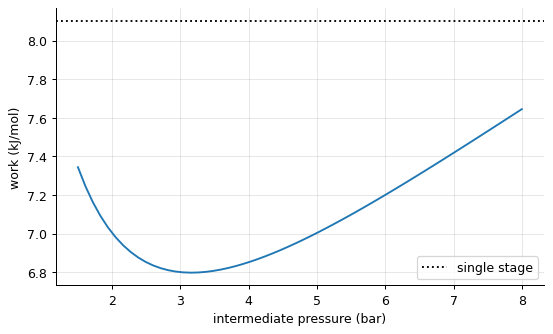

optimum intermediate pressure 3.15 bar (theory: sqrt(p1 p2) = 3.16 bar); saving 16.1%


In [5]:
def two_stage(p_mid):
    Ta = idealgas.isentropic_T("air", T1, p1, p_mid)
    Tb = idealgas.isentropic_T("air", T1, p_mid, p2)
    return idealgas.enthalpy_change("air", T1, Ta) + idealgas.enthalpy_change("air", T1, Tb)
p_mid = np.linspace(1.5e5, 8e5, 60)
w2 = np.array([two_stage(p) for p in p_mid])
plt.plot(p_mid / 1e5, w2 / 1e3); plt.axhline(w / 1e3, color="k", ls=":", label="single stage")
plt.xlabel("intermediate pressure (bar)"); plt.ylabel("work (kJ/mol)"); plt.legend(); plt.show()
best = p_mid[np.argmin(w2)]
print(f"optimum intermediate pressure {best/1e5:.2f} bar (theory: sqrt(p1 p2) = {np.sqrt(p1*p2)/1e5:.2f} bar); saving {1 - w2.min()/w:.1%}")

The optimum lies at the geometric mean of the pressures, where both stages do equal work, and it saves about
a sixth of the work. With more stages the process approaches isothermal compression, the minimum possible.

## Steam: a turbine and a throttling valve

In [6]:
inlet = steam.properties(T=773.15, p=8e6)
outlet_s = steam.state_ps(10e3, inlet["s"])                      # isentropic expansion to 10 kPa
w_s = inlet["h"] - outlet_s["h"]
print(f"turbine, 8 MPa / 500 degC -> 10 kPa: isentropic work {w_s/1e3:.1f} kJ/kg, exit quality {outlet_s['x']:.3f}")
valve_in = steam.properties(T=573.15, p=5e6)
valve_out = steam.state_ph(1e5, valve_in["h"])                   # throttling: h constant
print(f"throttling valve, 5 MPa / 300 degC -> 1 bar: outlet {valve_out['T'] - 273.15:.1f} degC, {valve_out['phase']}")

turbine, 8 MPa / 500 degC -> 10 kPa: isentropic work 1269.2 kJ/kg, exit quality 0.810
throttling valve, 5 MPa / 300 degC -> 1 bar: outlet 225.4 degC, vapour


A throttling valve does no work and exchanges no heat, so the enthalpy is unchanged - but the temperature
falls (the Joule-Thomson effect; an ideal gas would show none). The expansion in the turbine, by contrast,
delivers work equal to the enthalpy drop.

## Inside the algorithm: the enthalpy integral
`enthalpy_change` integrates the heat-capacity polynomial analytically; check it against numerical integration:

In [7]:
num = integrate.quad(lambda T: idealgas.cp("CO2", T), 400.0, 1200.0)[0]
print(f"numerical {num/1e3:.4f} kJ/mol, analytical {idealgas.enthalpy_change('CO2', 400.0, 1200.0)/1e3:.4f} kJ/mol")

numerical 40.4770 kJ/mol, analytical 40.4770 kJ/mol


## Exercises
1. A gas turbine's exhaust (mostly air, 1.5 kg/s at 750 K) heats water from 20 to 90 degC in a heat-recovery exchanger while cooling to 400 K. How much water can be heated per second? (Liquid water: cp = 4.18 kJ/(kg K).)
2. Three-stage compression of air from 1 to 27 bar with intercooling to 300 K: choose the intermediate pressures, compute the work, and compare with single-stage compression and with isothermal compression (RT ln(p2/p1)).
3. **Implement it yourself:** write `isentropic_T(gas, T1, p1, p2)` yourself using `entropy_change` and `brentq`, and reproduce the compressor outlet temperature of the notebook.